In [1]:
import pennylane as qml
from pennylane import qchem
import matplotlib
import numpy as np
import scipy

In [2]:
qml.data.list_attributes(data_name="qchem")

['basis_rot_groupings',
 'basis_rot_samples',
 'dipole_op',
 'fci_energy',
 'fci_spectrum',
 'hamiltonian',
 'hf_state',
 'initial_state_coeffs',
 'initial_state_dets',
 'molecule',
 'number_op',
 'optimal_sector',
 'paulix_ops',
 'qwc_groupings',
 'qwc_samples',
 'sparse_hamiltonian',
 'spin2_op',
 'spinz_op',
 'symmetries',
 'tapered_dipole_op',
 'tapered_hamiltonian',
 'tapered_hf_state',
 'tapered_num_op',
 'tapered_spin2_op',
 'tapered_spinz_op',
 'vqe_energy',
 'vqe_gates',
 'vqe_params']

In [3]:
part = qml.data.load(
    "qchem",
    molname="H2",
    basis="STO-3G",
    bondlength=0.74,
    attributes=["hamiltonian", "hf_state", "fci_energy"])[0]

H = part.hamiltonian
hf = part.hf_state
print(part.hamiltonian)
print(part.hf_state)

-0.09706822938423454 * I(0) + 0.17141259345958193 * Z(0) + 0.17141259345958193 * Z(1) + 0.1686889096740968 * (Z(0) @ Z(1)) + 0.04530263657517107 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.04530263657517107 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.04530263657517107 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.04530263657517107 * (X(0) @ Y(1) @ Y(2) @ X(3)) + -0.22343083178747108 * Z(2) + 0.12062514757360128 * (Z(0) @ Z(2)) + -0.22343083178747103 * Z(3) + 0.16592778414877235 * (Z(0) @ Z(3)) + 0.16592778414877235 * (Z(1) @ Z(2)) + 0.12062514757360128 * (Z(1) @ Z(3)) + 0.1744128054751057 * (Z(2) @ Z(3))
[1 1 0 0]


In [4]:
qml.BasisState(np.array([1,1,0,0]), wires=range(4))

theta = 0.1
qml.DoubleExcitation(theta, wires=range(4))


DoubleExcitation(0.1, wires=[0, 1, 2, 3])

In [5]:
import jax
jax.config.update("jax_platform_name", "cpu")
jax.config.update('jax_enable_x64', True)

qubits = range(4)
dev = qml.device("lightning.qubit", wires=qubits)

@qml.qnode(dev, interface="jax")
def circuit(param, wires):
    qml.BasisState(hf, wires=wires)
    qml.DoubleExcitation(param, wires=qubits)
    return qml.expval(H)

def cost_fn(param):
    return circuit(param, wires=qubits)

import optax

max_iterations = 100
conv_tol = 1e-06

opt = optax.sgd(learning_rate=0.4)



In [10]:
theta = np.array(0.0, dtype=np.float64)

energy  = [cost_fn(theta)]
angle = [theta]

opt_state = opt.init(theta)

for n in range(max_iterations):
    gradient = jax.grad(cost_fn)(theta)
    updates, opt_state = opt.update(gradient, opt_state)
    theta = optax.apply_updates(theta, updates)

    angle.append(theta)
    energy.append(cost_fn(theta))

    print(f'Step {n}, Energy = {energy[-1]}Ha')
    if n > 1:
        if energy[-1]- energy[-2] < conv_tol:
            break

print(f'Opimum at theta = {angle[-1]}')

Step 0, Energy = -1.1278090501061417Ha
Step 1, Energy = -1.1329343555957585Ha
Step 2, Energy = -1.1352923377236026Ha
Opimum at theta = 0.15543800324535234


d:\anaconda3\envs\qml2\Lib\site-packages\pennylane\math\interface_utils.py:137: UserWarning: Contains tensors of types {'autograd', 'jax'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


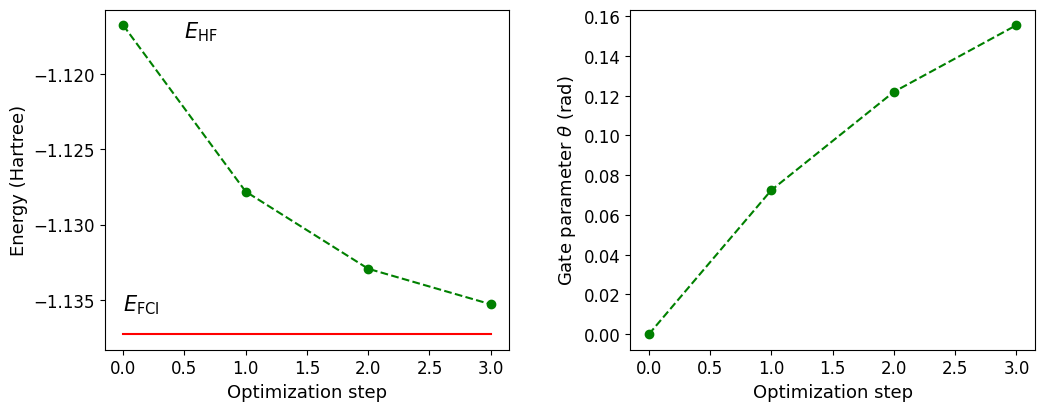

In [11]:
import matplotlib.pyplot as plt

fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(12)

# Full configuration interaction (FCI) energy computed classically
E_fci = part.fci_energy

# Add energy plot on column 1
ax1 = fig.add_subplot(121)
ax1.plot(range(n + 2), energy, "go", ls="dashed")
ax1.plot(range(n + 2), np.full(n + 2, E_fci), color="red")
ax1.set_xlabel("Optimization step", fontsize=13)
ax1.set_ylabel("Energy (Hartree)", fontsize=13)
ax1.text(0.5, -1.1176, r"$E_\mathrm{HF}$", fontsize=15)
ax1.text(0, -1.1357, r"$E_\mathrm{FCI}$", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add angle plot on column 2
ax2 = fig.add_subplot(122)
ax2.plot(range(n + 2), angle, "go", ls="dashed")
ax2.set_xlabel("Optimization step", fontsize=13)
ax2.set_ylabel("Gate parameter $\\theta$ (rad)", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()


In [12]:
@qml.qnode(dev, interface="jax", diff_method="parameter-shift")
def circuit(param, wires):
    qml.BasisState(hf, wires=wires)
    qml.DoubleExcitation(param, wires=qubits)
    return qml.expval(H)

def cost_fn(param):
    return circuit(param, wires=qubits)

import optax

max_iterations = 100
conv_tol = 1e-06

opt = optax.sgd(learning_rate=0.4)

In [16]:
theta = np.array(0.0, dtype=np.float64)

energy  = [cost_fn(theta)]
angle = [theta]

opt_state = opt.init(theta)

for n in range(max_iterations):
    gradient = jax.grad(cost_fn)(theta)
    updates, opt_state = opt.update(gradient, opt_state)
    theta = optax.apply_updates(theta, updates)

    angle.append(theta)
    energy.append(cost_fn(theta))

    print(f'Step {n}, Energy = {energy[-1]}Ha')
    if n > 1:
        if energy[-1]- energy[-2] < conv_tol:
            break

print(f'Opimum at theta = {angle[-1]}')

Step 0, Energy = -1.1278090501061417Ha
Step 1, Energy = -1.1329343555957585Ha
Step 2, Energy = -1.1352923377236026Ha
Opimum at theta = 0.15543800324535234


d:\anaconda3\envs\qml2\Lib\site-packages\pennylane\math\interface_utils.py:137: UserWarning: Contains tensors of types {'autograd', 'jax'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


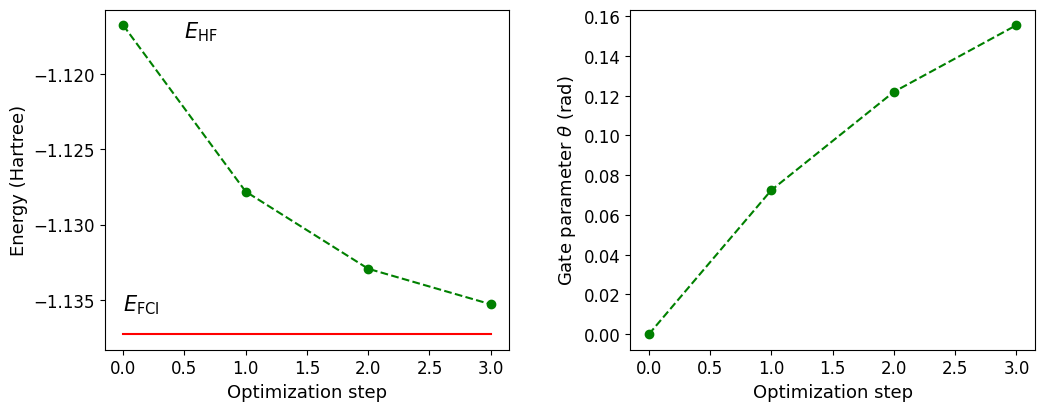

In [17]:
import matplotlib.pyplot as plt

fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(12)

# Full configuration interaction (FCI) energy computed classically
E_fci = part.fci_energy

# Add energy plot on column 1
ax1 = fig.add_subplot(121)
ax1.plot(range(n + 2), energy, "go", ls="dashed")
ax1.plot(range(n + 2), np.full(n + 2, E_fci), color="red")
ax1.set_xlabel("Optimization step", fontsize=13)
ax1.set_ylabel("Energy (Hartree)", fontsize=13)
ax1.text(0.5, -1.1176, r"$E_\mathrm{HF}$", fontsize=15)
ax1.text(0, -1.1357, r"$E_\mathrm{FCI}$", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add angle plot on column 2
ax2 = fig.add_subplot(122)
ax2.plot(range(n + 2), angle, "go", ls="dashed")
ax2.set_xlabel("Optimization step", fontsize=13)
ax2.set_ylabel("Gate parameter $\\theta$ (rad)", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()


In [18]:
dataset = part
hf_state = hf
n_qubits = len(hf_state)

print(f'Number of pauli terms: {len(H.ops)}')
for coeff, op in zip(H.coeffs, H.ops):
    print(f'{coeff} * {op}')

Number of pauli terms: 15
-0.09706822938423454 * I(0)
0.17141259345958193 * Z(0)
0.17141259345958193 * Z(1)
0.1686889096740968 * Z(0) @ Z(1)
0.04530263657517107 * Y(0) @ X(1) @ X(2) @ Y(3)
-0.04530263657517107 * Y(0) @ Y(1) @ X(2) @ X(3)
-0.04530263657517107 * X(0) @ X(1) @ Y(2) @ Y(3)
0.04530263657517107 * X(0) @ Y(1) @ Y(2) @ X(3)
-0.22343083178747108 * Z(2)
0.12062514757360128 * Z(0) @ Z(2)
-0.22343083178747103 * Z(3)
0.16592778414877235 * Z(0) @ Z(3)
0.16592778414877235 * Z(1) @ Z(2)
0.12062514757360128 * Z(1) @ Z(3)
0.1744128054751057 * Z(2) @ Z(3)


In [19]:
dev = qml.device('default.qubit', wires = n_qubits)

@qml.qnode(dev)
def vqe_circuit(params):
    qml.BasisState(hf_state, wires = range(n_qubits))
    qml.DoubleExcitation(params[0], wires = range(n_qubits))
    return qml.expval(H)

In [23]:
params = qml.numpy.array([0.0], requires_grad = True)

opt = qml.GradientDescentOptimizer(stepsize=0.4)
energies = []

for step in range(100):
    params, energy = opt.step_and_cost(vqe_circuit, params)
    energies.append(energy)
    print(f'step {step}: Energy = {energy} Ha')

print(f'Final energy = {energies[-1]} Ha, off by {1-energies[-1]/1.1373} % from the FCI energy')

step 0: Energy = -1.1167592281738852 Ha
step 1: Energy = -1.127809050106142 Ha
step 2: Energy = -1.1329343555957585 Ha
step 3: Energy = -1.135292337723602 Ha
step 4: Energy = -1.1363730713074285 Ha
step 5: Energy = -1.1368675428520372 Ha
step 6: Energy = -1.1370935997427782 Ha
step 7: Energy = -1.137196908182511 Ha
step 8: Energy = -1.1372441124697945 Ha
step 9: Energy = -1.1372656796812295 Ha
step 10: Energy = -1.137275533201788 Ha
step 11: Energy = -1.1372800349577654 Ha
step 12: Energy = -1.1372820916500388 Ha
step 13: Energy = -1.1372830312765057 Ha
step 14: Energy = -1.1372834605563595 Ha
step 15: Energy = -1.1372836566779794 Ha
step 16: Energy = -1.137283746278452 Ha
step 17: Energy = -1.1372837872134773 Ha
step 18: Energy = -1.1372838059151218 Ha
step 19: Energy = -1.1372838144591866 Ha
step 20: Energy = -1.137283818362642 Ha
step 21: Energy = -1.1372838201459812 Ha
step 22: Energy = -1.1372838209607206 Ha
step 23: Energy = -1.1372838213329435 Ha
step 24: Energy = -1.13728382150

In [25]:
theta = params
grad_param_shift = (vqe_circuit(theta + np.pi/2) - vqe_circuit(theta - np.pi/2)) / 2

eps = 1e-5
grad_finite_diff = (vqe_circuit(theta + eps) - vqe_circuit(theta - eps)) / (2 * eps)

print(f'Gradient from parameter-shift rule: {grad_param_shift}')
print(f'Gradient from finite-difference method: {grad_finite_diff}')
print(f'Gradient difference: {grad_param_shift - grad_finite_diff}')

Gradient from parameter-shift rule: -1.1102230246251565e-16
Gradient from finite-difference method: 0.0
Gradient difference: -1.1102230246251565e-16
